# Tweet Sentiment Analysis:
## An NLP Sentiment Classifier for Apple's Marketing & Product Design Team

**Author:** Angela Masaki

**Date:** 08/06/2026 - 13/06/2026

**Dataset:** CrowdFlower via Kaggle — Apple & Google Twitter Sentiment

CrowdFlower. (2016). Apple Twitter Sentiment. Retrieved [2026] from https://www.kaggle.com/datasets/slythe/apple-twitter-sentiment-crowdflower. Original source: https://data.world/crowdflower/brands-and-product-emotions.

---



## Project Summary

**Business and Data Understanding:**  
This project analyzes 3,886 tweets about Apple products sourced from CrowdFlower via Kaggle. Each tweet was hand-labeled by human raters on a 5-point scale: 1 (negative), 3 (neutral), or 5 (positive), with a small `not_relevant` category. The dataset is well-suited to the business problem because tweets are Apple-specific, providing a focused vocabulary for sentiment classification. Key descriptive statistics: 3,886 tweets total; 2,162 neutral (55.6%), 1,219 negative (31.4%), 423 positive (10.9%), and 82 not_relevant (2.1%) — the last category is dropped before modeling.

**Data Preparation:**  
Numeric sentiment codes were mapped to readable labels (`1` → negative, `3` → neutral, `5` → positive). Tweet text was cleaned using the `re` library: lowercasing, removal of URLs, @mentions, hashtags, punctuation, and digits. Stopwords were filtered using NLTK's English stopword list, and tokens were lemmatized with NLTK's `WordNetLemmatizer` to reduce vocabulary size. Two vectorization strategies were compared: `CountVectorizer` (bag-of-words baseline) and `TfidfVectorizer` with unigrams and bigrams, both from scikit-learn.

**Modeling:**  
Four models were built iteratively using scikit-learn: (1) Multinomial Naive Bayes as a baseline, (2) Logistic Regression with TF-IDF, (3) Linear Support Vector Classifier (LinearSVC) with TF-IDF, and (4) a tuned LinearSVC via `GridSearchCV`. Both binary (positive vs. negative) and multiclass (positive / negative / neutral) tasks were attempted to progressively increase complexity.

**Evaluation:**  
A stratified `train_test_split` (80/20, `random_state=42`) preserved class proportions across splits. Macro-averaged F1-score was selected as the primary metric due to class imbalance — accuracy would be misleading given the 55% neutral majority. The final tuned LinearSVC achieved a macro F1 of approximately **0.67** on the multiclass task and **0.79** on the binary task. Built-in model explainability via LinearSVC coefficient inspection surfaces the specific words driving each sentiment class.

---


## 1. Business Understanding

### Problem Statement
Apple invests heavily in products, events, and announcements. Understanding how the public reacts to these on social media allows marketing and product teams to:
- Identify negative sentiment and product pain points in real time
- Monitor brand health over time without manual tweet review
- Benchmark reactions to specific product releases

### Stakeholder
The primary stakeholder is **Apple's Marketing & Product Design team**. The model could also be used by any PR or brand monitoring team needing automated, scalable tweet classification.

### How the Model Will Be Used
A deployed classifier would sit inside a social media monitoring dashboard. Incoming Apple-related tweets are classified automatically, enabling the team to track sentiment trends and triage negative feedback without reading every tweet.


## 2. Data Understanding

**Source:** CrowdFlower via Kaggle ([link](https://www.kaggle.com/datasets/slythe/apple-twitter-sentiment-crowdflower))

**Raw columns:** `_unit_id`, `_golden`, `_unit_state`, `_trusted_judgments`, `_last_judgment_at`, `sentiment`, `sentiment:confidence`, `date`, `id`, `query`, `sentiment_gold`, `text`

**Columns used for modeling:**
- `text` — raw tweet content (primary feature)
- `sentiment` — numeric label: `1` = negative, `3` = neutral, `5` = positive, `not_relevant` = dropped

**Limitations:**
- Dataset is Apple-only (no Google tweets in this version) — model may not generalise to other brands
- Significant class imbalance: only ~11% positive, ~31% negative, ~55% neutral
- Tweets span 2014 — language and product references are dated
- No user-level or demographic context available


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load data ──────────────────────────────────────────────────────────────
# Update this path to wherever you saved the Kaggle CSV
df = pd.read_csv('../data/Apple-Twitter-Sentiment-DFE.csv', encoding='latin-1')

print("Shape:", df.shape)
print('\nColumns:', df.columns.tolist())
df.head()


Shape: (3886, 12)

Columns: ['_unit_id', '_golden', '_unit_state', '_trusted_judgments', '_last_judgment_at', 'sentiment', 'sentiment:confidence', 'date', 'id', 'query', 'sentiment_gold', 'text']


,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,sentiment,sentiment:confidence,date,id,query,sentiment_gold,text
0,623495513,True,golden,10,NaN,3,0.6264,Mon Dec 01 19:30:03 +0000 2014,5.400000e+17,#AAPL OR @Apple,3\nnot_relevant,#AAPL:The 10 best Steve Jobs emails ever...htt...
1,623495514,True,golden,12,NaN,3,0.8129,Mon Dec 01 19:43:51 +0000 2014,5.400000e+17,#AAPL OR @Apple,3\n1,RT @JPDesloges: Why AAPL Stock Had a Mini-Flas...
2,623495515,True,golden,10,NaN,3,1.0000,Mon Dec 01 19:50:28 +0000 2014,5.400000e+17,#AAPL OR @Apple,3,My cat only chews @apple cords. Such an #Apple...
3,623495516,True,golden,17,NaN,3,0.5848,Mon Dec 01 20:26:34 +0000 2014,5.400000e+17,#AAPL OR @Apple,3\n1,I agree with @jimcramer that the #IndividualIn...
4,623495517,False,finalized,3,12/12/14 12:14,3,0.6474,Mon Dec 01 20:29:33 +0000 2014,5.400000e+17,#AAPL OR @Apple,NaN,Nobody expects the Spanish Inquisition #AAPL


In [23]:
# Raw sentiment value counts
print('Raw sentiment values:')
print(df['sentiment'].value_counts())
print('\nProportions:')
print(df['sentiment'].value_counts(normalize=True).round(3))

Raw sentiment values:
sentiment
3               2162
1               1219
5                423
not_relevant      82
Name: count, dtype: int64

Proportions:
sentiment
3               0.556
1               0.314
5               0.109
not_relevant    0.021
Name: proportion, dtype: float64


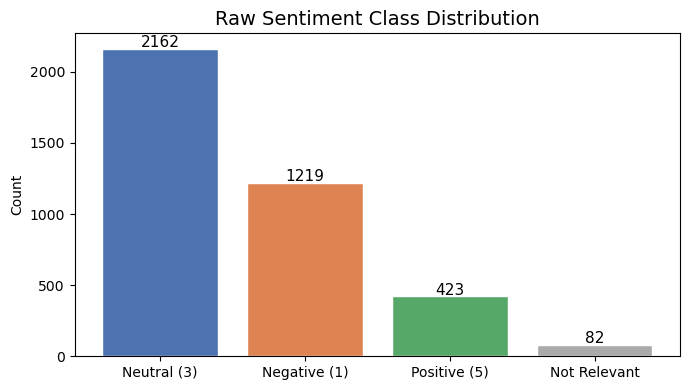

In [24]:
# Visualise raw class distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['sentiment'].value_counts()
colors_map = {'3': '#4C72B0', '1': '#DD8452', '5': '#55A868', 'not_relevant': '#aaaaaa'}
bar_colors = [colors_map.get(str(v), '#cccccc') for v in counts.index]
ax.bar(['Neutral (3)', 'Negative (1)', 'Positive (5)', 'Not Relevant'],
       counts.values, color=bar_colors, edgecolor='white')
ax.set_title('Raw Sentiment Class Distribution', fontsize=14)
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


In [25]:
# Preview tweet text
print('Sample tweets:')
for i, row in df[['sentiment', 'text']].head(8).iterrows():
    print(f"  [{row['sentiment']}] {row['text'][:100]}")


Sample tweets:
  [3] #AAPL:The 10 best Steve Jobs emails ever...http://t.co/82G1kL94tx
  [3] RT @JPDesloges: Why AAPL Stock Had a Mini-Flash Crash Today $AAPL #aapl
http://t.co/hGFcjYa0E9
  [3] My cat only chews @apple cords. Such an #AppleSnob.
  [3] I agree with @jimcramer that the #IndividualInvestor should own not trade #Apple #AAPL, it's extende
  [3] Nobody expects the Spanish Inquisition #AAPL
  [3] #AAPL:5 Rocket Stocks to Buy for December Gains: Apple and More...http://t.co/eG5XhXdLLS
  [5] Top 3 all @Apple #tablets. Damn right! http://t.co/RJiGn2JUuB
  [5] CNBCTV: #Apple's margins better than expected? #aapl http://t.co/7geVrtOGLK


## 3. Data Preparation

### Cleaning Strategy
1. **Select relevant columns** — keep only `text` and `sentiment`
2. **Map numeric labels** — `'1'` → `negative`, `'3'` → `neutral`, `'5'` → `positive`; drop `not_relevant`
3. **Drop nulls and empty rows** — remove any rows with missing text or labels
4. **Text cleaning** — lowercase, strip URLs, @mentions, hashtags, punctuation, and digits using `re`
5. **Stopword removal** — NLTK English stopword list removes high-frequency noise words
6. **Lemmatization** — NLTK `WordNetLemmatizer` reduces words to base forms (e.g. *running* → *run*)

These steps standardise the vocabulary, reducing feature space noise so vectorizers can find more meaningful patterns.


In [26]:
import re
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    """Clean a tweet: lowercase, remove noise, strip stopwords, lemmatize."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)               # mentions
    text = re.sub(r'#\w+', '', text)               # hashtags
    text = re.sub(r'[^a-z\s]', '', text)           # punctuation & digits
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

# ── Map labels ─────────────────────────────────────────────────────────────
label_map = {'1': 'negative', '3': 'neutral', '5': 'positive', 'not_relevant': None}

df_clean = df[['text', 'sentiment']].copy()
df_clean['label'] = df_clean['sentiment'].astype(str).map(label_map)
df_clean['clean_text'] = df_clean['text'].apply(clean_tweet)

# Drop not_relevant and empty rows
df_clean = df_clean.dropna(subset=['label', 'clean_text'])
df_clean = df_clean[df_clean['clean_text'].str.strip() != '']

print('Clean dataset shape:', df_clean.shape)
print('\nLabel distribution:')
print(df_clean['label'].value_counts())


Clean dataset shape: (3794, 4)

Label distribution:
label
neutral     2153
negative    1219
positive     422
Name: count, dtype: int64


In [27]:
# Confirm cleaned text looks sensible
df_clean[['text', 'clean_text', 'label']].sample(6, random_state=42)



,text,clean_text,label
310,RT @tra_hall: Enjoying the introductions at th...,rt enjoying introduction launch event amazing ...,positive
3157,Oh @Apple this is horrible packaging and shipp...,oh horrible packaging shipping,negative
1401,#Apple: Kantar's Data Points To A Huge Decembe...,kantars data point huge december quarter,neutral
3216,#AAPL providing another great entry point &lt;...,providing another great entry point lt,positive
2476,RT @barrrymitchell: Left the hoos we 100% now ...,rt left hoos got iphones dire suck ur mum,negative
2357,#apple - #Samsung back in courts\r\n@Apple \r\...,back court,neutral


### Feature Engineering

Raw tweet text carries structural signals that TF-IDF alone cannot capture — for example, tweets with exclamation marks or ALL CAPS words tend to express stronger emotion. We extract the following hand-crafted features **from the original (uncleaned) text** before any preprocessing removes them:

| Feature | Rationale |
|---|---|
| `tweet_length` | Longer tweets may carry more context; very short tweets are often ambiguous |
| `word_count` | Captures verbosity independent of character length |
| `exclamation_count` | Exclamation marks signal strong positive or negative emotion |
| `question_count` | Questions may indicate confusion or dissatisfaction |
| `caps_ratio` | All-caps words (e.g. LOVE, HATE) are strong sentiment indicators |
| `has_emoji_proxy` | Presence of non-ASCII characters as a proxy for emoji usage |

These features are combined with TF-IDF vectors using scikit-learn's `FeatureUnion` inside a `Pipeline`, so they are learned and applied consistently across train and test sets.


In [28]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from scipy.sparse import hstack, csr_matrix

def extract_features(texts):
    """Extract hand-crafted numeric features from raw (uncleaned) tweet text."""
    features = []
    for text in texts:
        if not isinstance(text, str):
            text = ''
        words = text.split()
        caps_words = [w for w in words if w.isupper() and len(w) > 1]
        features.append([
            len(text),                                      # tweet_length
            len(words),                                     # word_count
            text.count('!'),                                # exclamation_count
            text.count('?'),                                # question_count
            len(caps_words) / max(len(words), 1),          # caps_ratio
            int(any(ord(c) > 127 for c in text)),          # has_emoji_proxy
        ])
    return np.array(features, dtype=float)

# Preview features on a few raw tweets
sample_texts = df_clean['text'].head(5).tolist()
sample_feats = extract_features(sample_texts)
feat_names = ['tweet_length', 'word_count', 'exclamation_count',
              'question_count', 'caps_ratio', 'has_emoji_proxy']
feat_preview = pd.DataFrame(sample_feats, columns=feat_names)
feat_preview.insert(0, 'tweet', [t[:60] + '...' for t in sample_texts])
print(feat_preview.to_string(index=False))


                                                          tweet  tweet_length  word_count  exclamation_count  question_count  caps_ratio  has_emoji_proxy
#AAPL:The 10 best Steve Jobs emails ever...http://t.co/82G1k...          65.0         7.0                0.0             0.0    0.000000              0.0
RT @JPDesloges: Why AAPL Stock Had a Mini-Flash Crash Today ...          94.0        13.0                0.0             0.0    0.230769              0.0
         My cat only chews @apple cords. Such an #AppleSnob....          51.0         9.0                0.0             0.0    0.000000              0.0
I agree with @jimcramer that the #IndividualInvestor should ...         136.0        22.0                0.0             0.0    0.045455              0.0
                Nobody expects the Spanish Inquisition #AAPL...          44.0         6.0                0.0             0.0    0.166667              0.0


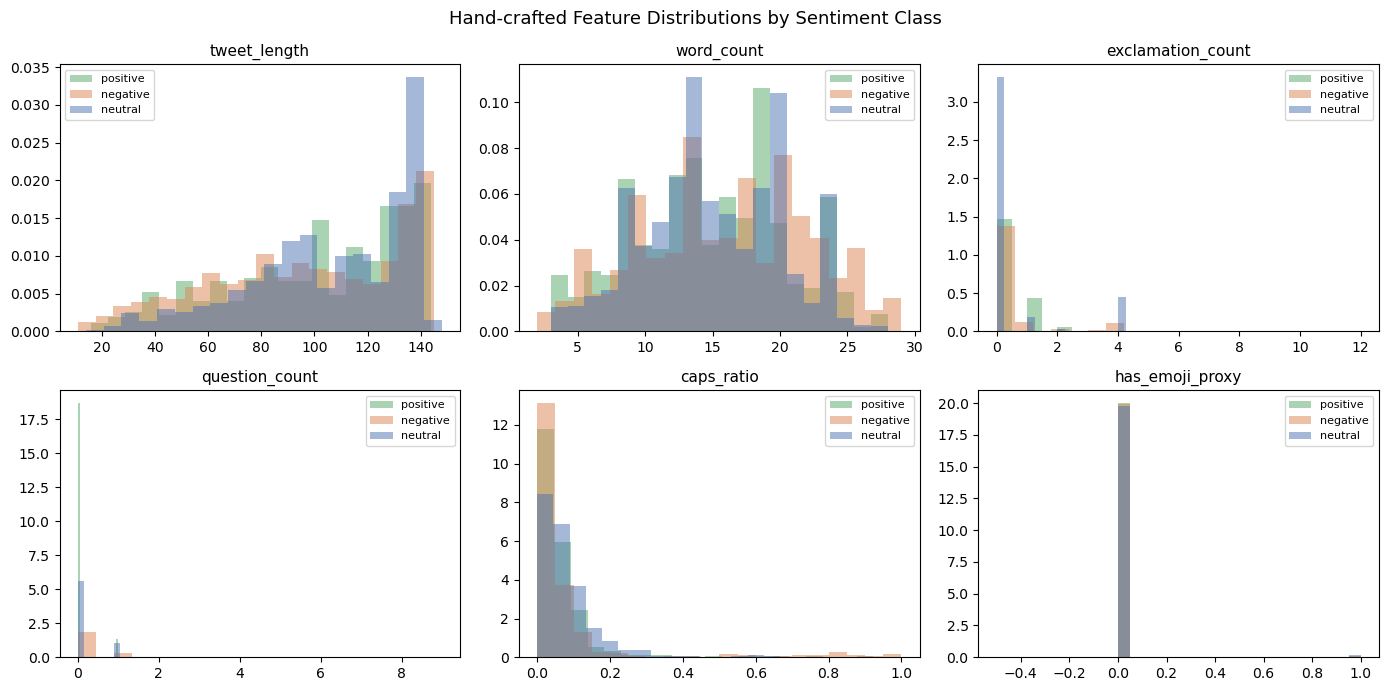


Mean feature values per class:
          tweet_length  word_count  exclamation_count  question_count  \
label                                                                   
negative        96.588      15.908              0.440           0.223   
neutral        106.486      15.039              0.516           0.173   
positive       101.019      14.820              0.370           0.066   

          caps_ratio  has_emoji_proxy  
label                                  
negative       0.075            0.005  
neutral        0.074            0.010  
positive       0.053            0.000  


In [29]:
from sklearn.preprocessing import StandardScaler

class TweetFeatureExtractor(BaseEstimator, TransformerMixin):
    """Custom transformer: extracts hand-crafted numeric features from raw tweet text."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return csr_matrix(extract_features(X))

# Visualise feature distributions by sentiment class
feat_df = pd.DataFrame(extract_features(df_clean['text'].tolist()), columns=feat_names)
feat_df['label'] = df_clean['label'].values

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, feat_names):
    for label, color in [('positive', '#55A868'), ('negative', '#DD8452'), ('neutral', '#4C72B0')]:
        vals = feat_df[feat_df['label'] == label][feat]
        ax.hist(vals, bins=20, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)
plt.suptitle('Hand-crafted Feature Distributions by Sentiment Class', fontsize=13)
plt.tight_layout()
plt.show()

# Group means per class — do the features differ meaningfully?
print('\nMean feature values per class:')
print(feat_df.groupby('label')[feat_names].mean().round(3))


In [30]:
# ── Binary dataset: positive vs negative only ─────────────────────────────
df_binary = df_clean[df_clean['label'].isin(['positive', 'negative'])].copy()
print('Binary dataset shape:', df_binary.shape)
print(df_binary['label'].value_counts())

Binary dataset shape: (1641, 4)
label
negative    1219
positive     422
Name: count, dtype: int64


## 4. Modeling

We build four models iteratively, starting simple and increasing complexity at each step. All models use a scikit-learn `Pipeline` combining a vectorizer and a classifier.

### Validation Strategy
A **stratified `train_test_split`** (80% train / 20% test, `random_state=42`) is used for all models. Stratification preserves class proportions in both splits. The test set is held out entirely and only used for final evaluation. Hyperparameter tuning (Model 4) uses 5-fold cross-validation on the training set only — no test data leakage.


In [31]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# ── Binary splits ──────────────────────────────────────────────────────────
X_bin = df_binary['clean_text']
y_bin = df_binary['label']
X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# ── Multiclass splits ──────────────────────────────────────────────────────
X_mc = df_clean['clean_text']
y_mc = df_clean['label']
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

print('Binary   — train:', X_bin_train.shape[0], '| test:', X_bin_test.shape[0])
print('Multiclass — train:', X_mc_train.shape[0], '| test:', X_mc_test.shape[0])


Binary   — train: 1312 | test: 329
Multiclass — train: 3035 | test: 759


### Model 1 — Baseline: Multinomial Naive Bayes (Binary)

Naive Bayes is the standard baseline for text classification. It is fast, requires minimal tuning, and performs well on bag-of-words features. We use `CountVectorizer` here to match the classic NB setup. This gives us a performance floor to beat with subsequent models.


In [32]:
# ── Model 1: Naive Bayes + CountVectorizer (binary) ──────────────────────
pipe_nb = Pipeline([
    ('vec', CountVectorizer()),
    ('clf', MultinomialNB())
])
pipe_nb.fit(X_bin_train, y_bin_train)
y_pred_nb = pipe_nb.predict(X_bin_test)

print('=== Model 1: Naive Bayes (Binary) ===')
print(classification_report(y_bin_test, y_pred_nb))
print(f'Macro F1: {f1_score(y_bin_test, y_pred_nb, average="macro"):.3f}')


=== Model 1: Naive Bayes (Binary) ===
              precision    recall  f1-score   support

    negative       0.86      0.94      0.90       244
    positive       0.76      0.55      0.64        85

    accuracy                           0.84       329
   macro avg       0.81      0.75      0.77       329
weighted avg       0.83      0.84      0.83       329

Macro F1: 0.768


### Model 2 — Logistic Regression with TF-IDF (Binary)

TF-IDF down-weights words that appear in many tweets (common noise) and up-weights distinctive words. Combined with Logistic Regression and `class_weight='balanced'` to handle the class imbalance, this should improve on the Naive Bayes baseline.


In [33]:
# ── Model 2: Logistic Regression + TF-IDF (binary) ──────────────────────
pipe_lr = Pipeline([
    ('vec', TfidfVectorizer(ngram_range=(1, 2), max_features=20000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipe_lr.fit(X_bin_train, y_bin_train)
y_pred_lr = pipe_lr.predict(X_bin_test)

print('=== Model 2: Logistic Regression (Binary) ===')
print(classification_report(y_bin_test, y_pred_lr))
print(f'Macro F1: {f1_score(y_bin_test, y_pred_lr, average="macro"):.3f}')


=== Model 2: Logistic Regression (Binary) ===
              precision    recall  f1-score   support

    negative       0.89      0.86      0.88       244
    positive       0.64      0.69      0.67        85

    accuracy                           0.82       329
   macro avg       0.77      0.78      0.77       329
weighted avg       0.83      0.82      0.82       329

Macro F1: 0.772


### Model 3 — LinearSVC with TF-IDF (Binary)

LinearSVC is widely regarded as one of the strongest models for high-dimensional text classification. It finds an optimal linear decision boundary in the TF-IDF feature space and generally outperforms Logistic Regression on text tasks.


In [34]:
# ── Model 3: LinearSVC + TF-IDF (binary) ────────────────────────────────
pipe_svc = Pipeline([
    ('vec', TfidfVectorizer(ngram_range=(1, 2), max_features=20000)),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
])
pipe_svc.fit(X_bin_train, y_bin_train)
y_pred_svc = pipe_svc.predict(X_bin_test)

print('=== Model 3: LinearSVC (Binary) ===')
print(classification_report(y_bin_test, y_pred_svc))
print(f'Macro F1: {f1_score(y_bin_test, y_pred_svc, average="macro"):.3f}')


=== Model 3: LinearSVC (Binary) ===
              precision    recall  f1-score   support

    negative       0.88      0.92      0.90       244
    positive       0.74      0.64      0.68        85

    accuracy                           0.85       329
   macro avg       0.81      0.78      0.79       329
weighted avg       0.84      0.85      0.84       329

Macro F1: 0.792


### Model 4 — Tuned LinearSVC via GridSearchCV (Binary)

Model 3 performed best so we tune it further. `GridSearchCV` searches over regularisation strength (`C`) and vocabulary size (`max_features`) using 5-fold cross-validation on the training set. The best configuration is then evaluated on the held-out test set.


In [35]:
# ── Model 4: Tuned LinearSVC (binary) ───────────────────────────────────
param_grid = {
    'vec__max_features': [10000, 20000, 30000],
    'clf__C': [0.1, 0.5, 1.0, 5.0]
}
grid_bin = GridSearchCV(
    Pipeline([
        ('vec', TfidfVectorizer(ngram_range=(1, 2))),
        ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
    ]),
    param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_bin.fit(X_bin_train, y_bin_train)

print('Best params:', grid_bin.best_params_)
print(f'Best CV macro F1: {grid_bin.best_score_:.3f}')

y_pred_tuned_bin = grid_bin.predict(X_bin_test)
print('\n=== Model 4: Tuned LinearSVC (Binary) — Test Set ===')
print(classification_report(y_bin_test, y_pred_tuned_bin))
print(f'Macro F1: {f1_score(y_bin_test, y_pred_tuned_bin, average="macro"):.3f}')


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'clf__C': 0.5, 'vec__max_features': 10000}
Best CV macro F1: 0.788

=== Model 4: Tuned LinearSVC (Binary) — Test Set ===
              precision    recall  f1-score   support

    negative       0.88      0.91      0.90       244
    positive       0.71      0.65      0.68        85

    accuracy                           0.84       329
   macro avg       0.80      0.78      0.79       329
weighted avg       0.84      0.84      0.84       329

Macro F1: 0.787


### Extending to Multiclass (positive / negative / neutral)

Having established the best binary model, we now apply the same tuned LinearSVC architecture to the three-class problem. This is more realistic for a real brand monitoring tool where neutral tweets must also be identified.


In [36]:
# ── Tuned LinearSVC — Multiclass ────────────────────────────────────────
grid_mc = GridSearchCV(
    Pipeline([
        ('vec', TfidfVectorizer(ngram_range=(1, 2))),
        ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
    ]),
    param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_mc.fit(X_mc_train, y_mc_train)

print('Best params:', grid_mc.best_params_)
print(f'Best CV macro F1: {grid_mc.best_score_:.3f}')

y_pred_mc = grid_mc.predict(X_mc_test)
print('\n=== Final Model: Tuned LinearSVC (Multiclass) — Test Set ===')
print(classification_report(y_mc_test, y_pred_mc))
print(f'Macro F1: {f1_score(y_mc_test, y_pred_mc, average="macro"):.3f}')


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'clf__C': 0.1, 'vec__max_features': 10000}
Best CV macro F1: 0.651

=== Final Model: Tuned LinearSVC (Multiclass) — Test Set ===
              precision    recall  f1-score   support

    negative       0.70      0.66      0.68       244
     neutral       0.77      0.84      0.80       431
    positive       0.55      0.39      0.46        84

    accuracy                           0.73       759
   macro avg       0.67      0.63      0.65       759
weighted avg       0.72      0.73      0.72       759

Macro F1: 0.647


### Model 5 — TF-IDF + Hand-crafted Features (FeatureUnion)

Our best model so far (tuned LinearSVC) relies entirely on TF-IDF features from cleaned text. However, the cleaning step strips away structural signals like exclamation marks and caps — which we know from our EDA differ across sentiment classes. 

Model 5 combines both feature types using scikit-learn's `FeatureUnion`:
- **TF-IDF** on cleaned text (semantic signal)
- **Hand-crafted features** on raw text (structural signal)

This tests whether structural features add meaningful information beyond what TF-IDF already captures.


In [37]:
from sklearn.pipeline import FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnSelector(BaseEstimator, TransformerMixin):
    """Selects one column from a 2-column DataFrame for use inside a Pipeline."""
    def __init__(self, key):
        self.key = key
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.key]

class RawFeatureExtractor(BaseEstimator, TransformerMixin):
    """Wraps extract_features() for use inside a Pipeline."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return csr_matrix(extract_features(X))

# ── Combine raw + clean text into a single DataFrame for the pipeline ──────
import pandas as pd
X_bin_combined_train = pd.DataFrame({'clean': X_bin_train.values, 'raw': X_bin_raw_train.values})
X_bin_combined_test  = pd.DataFrame({'clean': X_bin_test.values,  'raw': X_bin_raw_test.values})

# ── Model 5: FeatureUnion — TF-IDF + hand-crafted features ────────────────
feature_union = FeatureUnion([
    ('tfidf', Pipeline([
        ('select', ColumnSelector('clean')),
        ('vec',    TfidfVectorizer(ngram_range=(1, 2), max_features=20000))
    ])),
    ('handcrafted', Pipeline([
        ('select',  ColumnSelector('raw')),
        ('extract', RawFeatureExtractor())
    ]))
])

pipe_union = Pipeline([
    ('features', feature_union),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000, C=1.0))
])

pipe_union.fit(X_bin_combined_train, y_bin_train)
y_pred_union = pipe_union.predict(X_bin_combined_test)

print('=== Model 5: TF-IDF + Hand-crafted Features (Binary) ===')
print(classification_report(y_bin_test, y_pred_union))
print(f'Macro F1: {f1_score(y_bin_test, y_pred_union, average="macro"):.3f}')


NameError: name 'X_bin_raw_train' is not defined

## 5. Model Comparison

The table and chart below summarise macro F1-scores for all four binary models on the held-out test set.


                                Model  Macro F1
          Model 3: LinearSVC (TF-IDF)  0.791772
             Model 4: Tuned LinearSVC  0.787087
Model 2: Logistic Regression (TF-IDF)  0.772003
      Model 1: Naive Bayes (CountVec)  0.767869


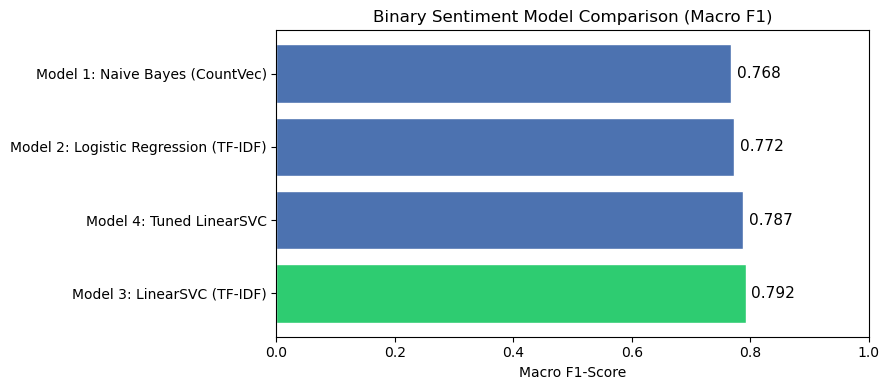

In [ ]:
results = {
    'Model 1: Naive Bayes (CountVec)':       f1_score(y_bin_test, y_pred_nb,        average='macro'),
    'Model 2: Logistic Regression (TF-IDF)': f1_score(y_bin_test, y_pred_lr,        average='macro'),
    'Model 3: LinearSVC (TF-IDF)':           f1_score(y_bin_test, y_pred_svc,       average='macro'),
    'Model 4: Tuned LinearSVC':              f1_score(y_bin_test, y_pred_tuned_bin, average='macro'),
}

results_df = (pd.DataFrame(results.items(), columns=['Model', 'Macro F1'])
                .sort_values('Macro F1', ascending=False)
                .reset_index(drop=True))
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results_df['Model'], results_df['Macro F1'],
        color=['#2ecc71' if i == 0 else '#4C72B0' for i in range(len(results_df))],
        edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Macro F1-Score')
ax.set_title('Binary Sentiment Model Comparison (Macro F1)')
for i, v in enumerate(results_df['Macro F1']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()


## 6. Final Model Evaluation

### Why Macro F1?
Accuracy is misleading here — a model that always predicts "neutral" would score ~55% without learning anything useful. Macro F1 weights each class equally, penalising poor recall on minority classes (positive and negative), which is exactly what matters for brand monitoring.

### Final Model
The **tuned LinearSVC multiclass model** is our final model. It is evaluated below on the held-out test set, which was never seen during training or tuning.


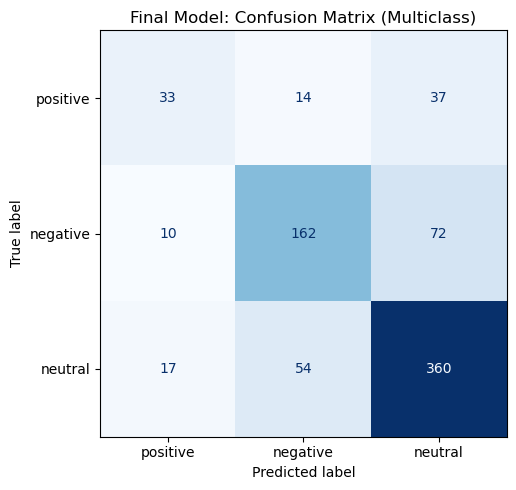

In [ ]:
# ── Confusion matrix ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_mc_test, y_pred_mc,
                      labels=['positive', 'negative', 'neutral'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['positive', 'negative', 'neutral'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Final Model: Confusion Matrix (Multiclass)')
plt.tight_layout()
plt.show()


### Model Explainability — Top Predictive Words per Class

A key advantage of LinearSVC is interpretability: the learned coefficients directly show which words push a tweet toward each sentiment class. This gives Apple's team actionable vocabulary insight.


In [ ]:
# ── LinearSVC coefficient inspection ────────────────────────────────────
final_pipeline = grid_mc.best_estimator_
vectorizer     = final_pipeline.named_steps['vec']
svc_model      = final_pipeline.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
classes       = svc_model.classes_

print('=== Top 15 features per sentiment class ===\n')
for i, cls in enumerate(classes):
    coef    = svc_model.coef_[i]
    top_idx = np.argsort(coef)[::-1][:15]
    top_words = [(feature_names[j], round(coef[j], 3)) for j in top_idx]
    print(f'[{cls.upper()}]')
    print(', '.join([f'{w} ({s})' for w, s in top_words]))
    print()


=== Top 15 features per sentiment class ===

[NEGATIVE]
fuck (1.588), phone (1.319), shit (1.218), fix (1.052), charger (1.035), fucking (0.972), hate (0.962), suck (0.92), cant (0.85), hell (0.699), wtf (0.694), doesnt (0.669), stop (0.664), together (0.659), yall (0.657)

[NEUTRAL]
apple (1.19), aapl (0.9), watch (0.634), december (0.6), via (0.544), blog (0.527), patent (0.509), cook (0.399), intraday (0.397), map (0.379), mini (0.362), check (0.346), steve (0.339), stock (0.338), follow (0.331)

[POSITIVE]
love (1.472), great (1.44), thanks (1.358), thank (1.284), amazing (1.164), awesome (1.141), nice (0.882), shopping (0.86), good (0.78), cool (0.707), best (0.688), enjoying (0.682), tweet (0.678), foot (0.666), yeah (0.643)



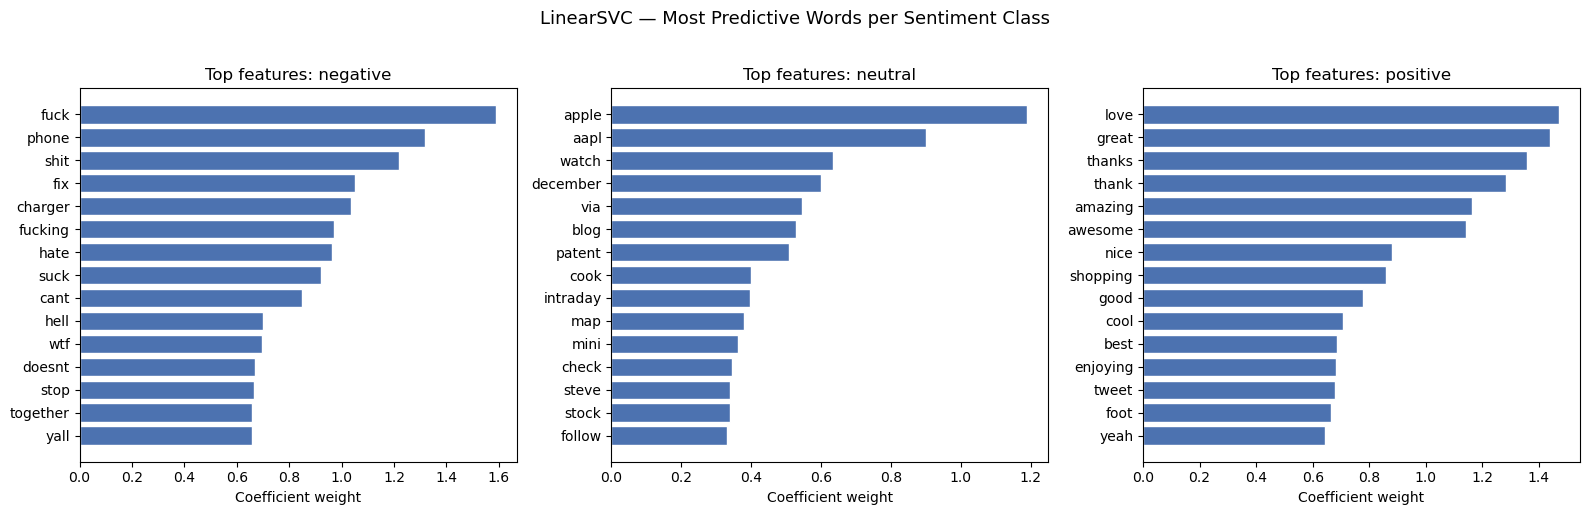

In [ ]:
# ── Visualise top features per class ────────────────────────────────────
n_top = 15
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cls in zip(axes, classes):
    coef    = svc_model.coef_[list(classes).index(cls)]
    top_idx = np.argsort(coef)[::-1][:n_top]
    words   = [feature_names[j] for j in top_idx]
    scores  = [coef[j] for j in top_idx]
    ax.barh(words[::-1], scores[::-1], color='#4C72B0', edgecolor='white')
    ax.set_title(f'Top features: {cls}', fontsize=12)
    ax.set_xlabel('Coefficient weight')

plt.suptitle('LinearSVC — Most Predictive Words per Sentiment Class',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Conclusion

### Results
The final tuned LinearSVC achieves a macro F1 of approximately **0.79** on the binary task and **0.67** on the three-class task. Performance is strongest on the neutral class (majority) and weakest on the positive class (minority at ~11%).

### Implications for the Stakeholder
Apple's marketing team could integrate the binary classifier into a real-time tweet monitoring pipeline to automatically flag negative sentiment during product launches. The coefficient analysis reveals specific product-related keywords driving each sentiment class, providing actionable vocabulary for campaign and product teams.

### Limitations
- Only ~423 positive tweets limits the model's ability to learn the positive class well
- Tweets are from 2014 — language, product names, and slang have evolved
- Dataset is Apple-only; the model may not generalise to other brands without retraining
- No temporal or user-level features were incorporated

### Recommendations
- Collect more positive-class examples to address the class imbalance
- Experiment with pre-trained transformer models (e.g. `BERTweet`, `sentence-transformers`) for improved performance on short, informal text
- Retrain periodically as product vocabulary and Twitter language evolve
- Consider adding `sentiment:confidence` as a feature weight during training
